# SHAP, LIME, SOM comparison on a mixed-type public tabular dataset

This notebook trains a small PyTorch MLP on the UCI Adult income dataset and compares SHAP, LIME, and SOM on the same model. The dataset is public, binary classification, and contains both numeric and categorical variables.

## 1. Why this dataset

The UCI Adult dataset is a public binary classification benchmark for predicting whether income exceeds $50K/year. It includes both categorical and integer features, which makes it more realistic for tabular XAI than a purely numeric toy dataset.

## 2. Package installation

Install the required libraries. If your environment already has them, this cell is harmless.

In [1]:
%pip -q install ucimlrepo shap lime minisom torch scikit-learn pandas numpy matplotlib seaborn plotly


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


## 3. Imports and seed setup

In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 4. Load the UCI Adult dataset

This dataset predicts whether annual income exceeds $50K/year and contains mixed feature types. We fetch it directly through `ucimlrepo`, so no Kaggle authentication is required.

In [3]:
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
X_raw = adult.data.features.copy()
y_raw = adult.data.targets.copy()

if isinstance(y_raw, pd.DataFrame):
    y_series = y_raw.iloc[:, 0]
else:
    y_series = pd.Series(y_raw)

y_series = y_series.astype(str).str.strip().replace({'>50K.': '>50K', '<=50K.': '<=50K'})
y = (y_series == '>50K').astype(int)

df = X_raw.copy()
df['target'] = y
print('Shape:', df.shape)
print('Target distribution:')
print(df['target'].value_counts())
df.head()


Shape: (48842, 15)
Target distribution:
target
0    37155
1    11687
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


## 5. Quick inspection

The Adult dataset contains missing values in some categorical columns, often encoded as `?`. We normalize those to `NaN` before building the preprocessing pipeline.

In [4]:
display(df.head())
print('\nDtypes:')
print(df.dtypes)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace('?', np.nan)

print('\nMissing values after cleanup:')
print(df.isna().sum().sort_values(ascending=False).head(10))


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0



Dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
target             int64
dtype: object

Missing values after cleanup:
occupation        1843
workclass         1836
native-country     583
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
dtype: int64


## 6. Preprocess the mixed-type tabular data

We keep the pipeline explicit:

- numeric: median imputation + standard scaling
- categorical: most-frequent imputation + one-hot encoding
- train/test split: stratified by target


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_COL = 'target'
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', onehot)])

preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_cols), ('cat', categorical_pipe, categorical_cols)], remainder='drop', verbose_feature_names_out=False)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out().tolist()

print('Numeric columns    :', len(numeric_cols))
print('Categorical columns:', len(categorical_cols))
print('Train shape        :', X_train.shape)
print('Test shape         :', X_test.shape)


Numeric columns    : 6
Categorical columns: 8
Train shape        : (39073, 108)
Test shape         : (9769, 108)


## 7. Build and train a small PyTorch MLP

The model uses three hidden layers with ReLU and dropout. A `latent()` method is exposed so that SOM can visualize the learned representation space in addition to the original processed feature space.

Device: cuda


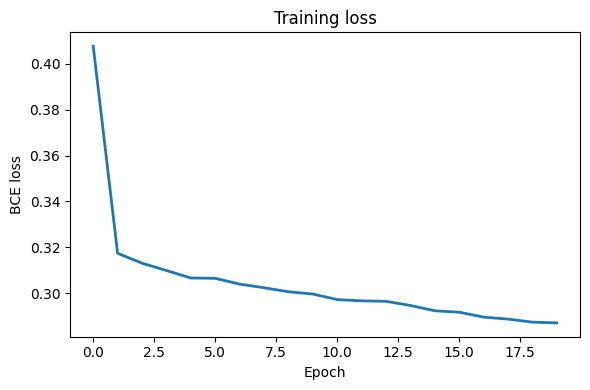

,split,roc_auc,average_precision,accuracy_at_0.5
0,train,0.932147,0.829736,0.873621
1,test,0.912566,0.783379,0.860170


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

class TabularMLP(nn.Module):
    """Small MLP for binary classification on tabular data."""

    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout: float = 0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
            prev_dim = hidden_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_dim, 1)

    def forward(self, x):
        z = self.feature_extractor(x)
        return self.classifier(z)

    def latent(self, x):
        return self.feature_extractor(x)

model = TabularMLP(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    loss_history.append(running_loss / len(train_loader.dataset))

plt.figure(figsize=(6, 4))
plt.plot(loss_history, linewidth=2)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    train_prob = torch.sigmoid(model(X_train_t.to(device))).cpu().numpy().ravel()
    test_prob = torch.sigmoid(model(X_test_t.to(device))).cpu().numpy().ravel()

metrics_df = pd.DataFrame({
    'split': ['train', 'test'],
    'roc_auc': [roc_auc_score(y_train, train_prob), roc_auc_score(y_test, test_prob)],
    'average_precision': [average_precision_score(y_train, train_prob), average_precision_score(y_test, test_prob)],
    'accuracy_at_0.5': [accuracy_score(y_train, train_prob >= 0.5), accuracy_score(y_test, test_prob >= 0.5)],
})
metrics_df


## 8. SHAP analysis

We use `shap.DeepExplainer` on the trained MLP. The notebook produces a global mean absolute importance view and a local instance-level explanation.

In [7]:
import shap

background_size = min(128, len(X_train))
explain_size = min(256, len(X_test))
background_idx = np.random.choice(len(X_train), size=background_size, replace=False)
explain_idx = np.random.choice(len(X_test), size=explain_size, replace=False)

background = torch.tensor(X_train[background_idx], dtype=torch.float32).to(device)
to_explain = torch.tensor(X_test[explain_idx], dtype=torch.float32).to(device)

model.eval()
shap_explainer = shap.DeepExplainer(model, background)
shap_values = shap_explainer.shap_values(to_explain)

if isinstance(shap_values, list):
    shap_arr = np.array(shap_values[0])
else:
    shap_arr = np.array(shap_values)

if shap_arr.ndim == 3:
    shap_arr = shap_arr[..., 0]

print('SHAP array shape:', shap_arr.shape)


SHAP array shape: (256, 108)


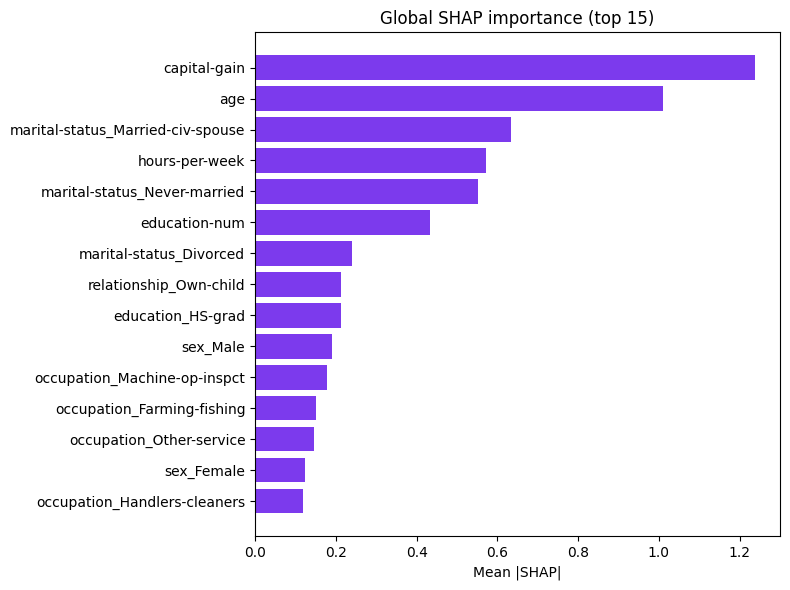

,feature,mean_abs_shap
3,capital-gain,1.237962
0,age,1.009439
33,marital-status_Married-civ-spouse,0.632612
5,hours-per-week,0.572246
35,marital-status_Never-married,0.551979
2,education-num,0.432797
31,marital-status_Divorced,0.239523
56,relationship_Own-child,0.212347
26,education_HS-grad,0.211905
65,sex_Male,0.191033


In [8]:
global_shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': np.abs(shap_arr).mean(axis=0)})
global_shap_df = global_shap_df.sort_values('mean_abs_shap', ascending=False)

top_global = global_shap_df.head(15).sort_values('mean_abs_shap')
plt.figure(figsize=(8, 6))
plt.barh(top_global['feature'], top_global['mean_abs_shap'], color='#7c3aed')
plt.title('Global SHAP importance (top 15)')
plt.xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()

global_shap_df.head(15)


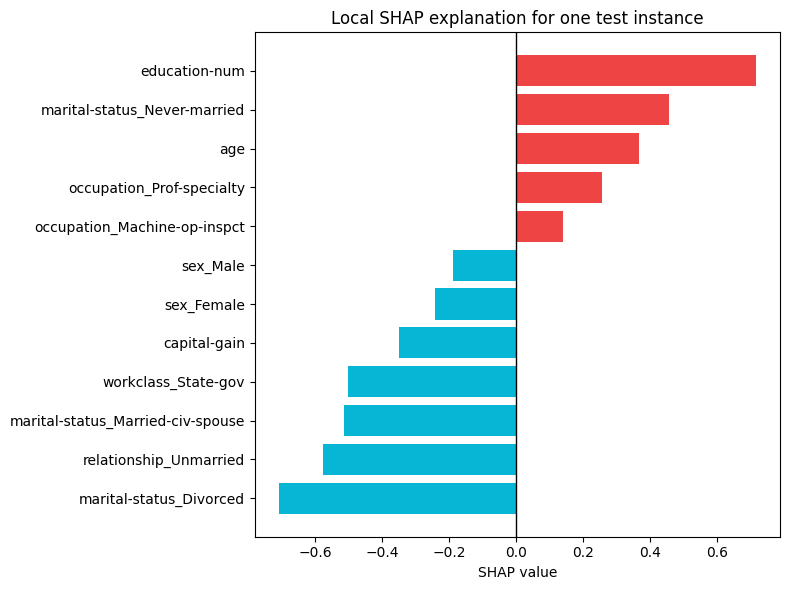

,feature,shap_value,abs_value
31,marital-status_Divorced,-0.708846,0.708846
57,relationship_Unmarried,-0.576172,0.576172
33,marital-status_Married-civ-spouse,-0.514847,0.514847
12,workclass_State-gov,-0.502803,0.502803
3,capital-gain,-0.350038,0.350038
64,sex_Female,-0.244222,0.244222
65,sex_Male,-0.190290,0.190290
44,occupation_Machine-op-inspct,0.140149,0.140149
47,occupation_Prof-specialty,0.257151,0.257151
0,age,0.365636,0.365636


In [9]:
local_index = 0
local_shap_df = pd.DataFrame({'feature': feature_names, 'shap_value': shap_arr[local_index]})
local_shap_df['abs_value'] = local_shap_df['shap_value'].abs()
local_shap_df = local_shap_df.sort_values('abs_value', ascending=False).head(12).sort_values('shap_value')

colors = np.where(local_shap_df['shap_value'] >= 0, '#ef4444', '#06b6d4')
plt.figure(figsize=(8, 6))
plt.barh(local_shap_df['feature'], local_shap_df['shap_value'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Local SHAP explanation for one test instance')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()

local_shap_df


## 9. LIME analysis

LIME approximates the neural network locally around one prediction using perturbations and a surrogate linear model.

LIME predicted probabilities: [9.9982470e-01 1.7532044e-04]
LIME explanation labels available: [0]
Using label: 0


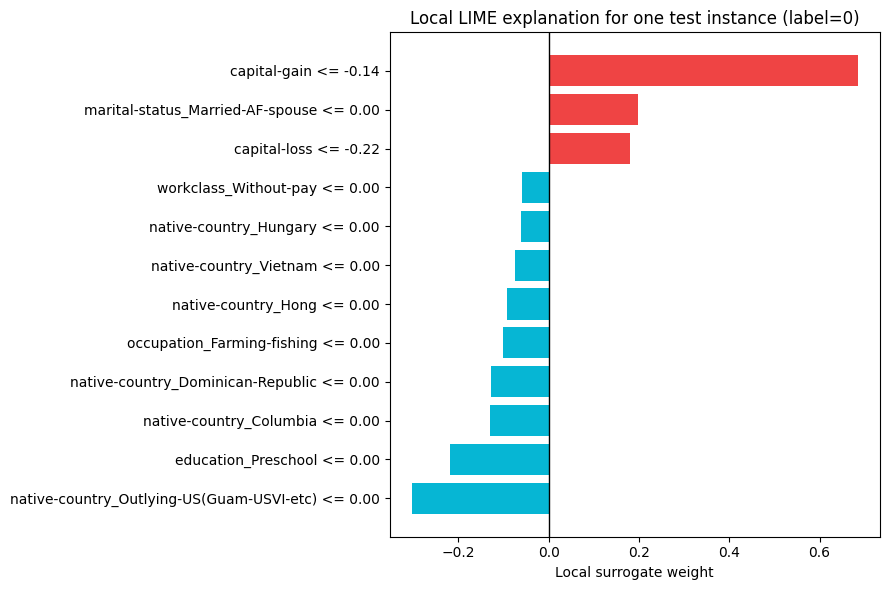

,feature_rule,weight
1,native-country_Outlying-US(Guam-USVI-etc) <= 0.00,-0.302992
2,education_Preschool <= 0.00,-0.218551
5,native-country_Columbia <= 0.00,-0.129580
6,native-country_Dominican-Republic <= 0.00,-0.126872
7,occupation_Farming-fishing <= 0.00,-0.101048
8,native-country_Hong <= 0.00,-0.092214
9,native-country_Vietnam <= 0.00,-0.073848
10,native-country_Hungary <= 0.00,-0.061183
11,workclass_Without-pay <= 0.00,-0.058269
4,capital-loss <= -0.22,0.179502


In [11]:
from lime.lime_tabular import LimeTabularExplainer

def predict_proba_np(x_np: np.ndarray) -> np.ndarray:
    """Return class probabilities for LIME."""
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
        prob_1 = torch.sigmoid(model(x_tensor)).cpu().numpy().ravel()
    return np.column_stack([1 - prob_1, prob_1])

class_names = ['<=50K', '>50K']
lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
)

lime_instance_index = 0

# Compute predicted probabilities and label for this instance
lime_probs = predict_proba_np(X_test[lime_instance_index:lime_instance_index + 1])[0]
predicted_label = int(np.argmax(lime_probs))

# Ask LIME to explain only that label
lime_exp = lime_explainer.explain_instance(
    X_test[lime_instance_index],
    predict_proba_np,
    num_features=12,
    labels=(predicted_label,),
)

print("LIME predicted probabilities:", lime_probs)
print("LIME explanation labels available:", sorted(lime_exp.local_exp.keys()))
print("Using label:", predicted_label)

# Use the existing label key instead of hard-coding 1
lime_df = (
    pd.DataFrame(
        lime_exp.as_list(label=predicted_label),
        columns=["feature_rule", "weight"],
    )
    .sort_values("weight")
)

colors = np.where(lime_df["weight"] >= 0, "#ef4444", "#06b6d4")

plt.figure(figsize=(9, 6))
plt.barh(lime_df["feature_rule"], lime_df["weight"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Local LIME explanation for one test instance (label={predicted_label})")
plt.xlabel("Local surrogate weight")
plt.tight_layout()
plt.show()

lime_df

## 10. SOM on processed input space and latent space

We train one SOM on the processed one-hot feature space and another SOM on the hidden representation learned by the MLP. This gives a structural global view that SHAP and LIME do not directly provide.

In [12]:
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler

som_side = 10

som_input = MiniSom(som_side, som_side, X_train.shape[1], sigma=1.2, learning_rate=0.5, random_seed=SEED)
som_input.random_weights_init(X_train)
som_input.train_random(X_train, 3000, verbose=False)

model.eval()
with torch.no_grad():
    Z_train = model.latent(X_train_t.to(device)).cpu().numpy()
    Z_test = model.latent(X_test_t.to(device)).cpu().numpy()

latent_scaler = StandardScaler()
Z_train_scaled = latent_scaler.fit_transform(Z_train)
Z_test_scaled = latent_scaler.transform(Z_test)

som_latent = MiniSom(som_side, som_side, Z_train_scaled.shape[1], sigma=1.2, learning_rate=0.5, random_seed=SEED)
som_latent.random_weights_init(Z_train_scaled)
som_latent.train_random(Z_train_scaled, 3000, verbose=False)


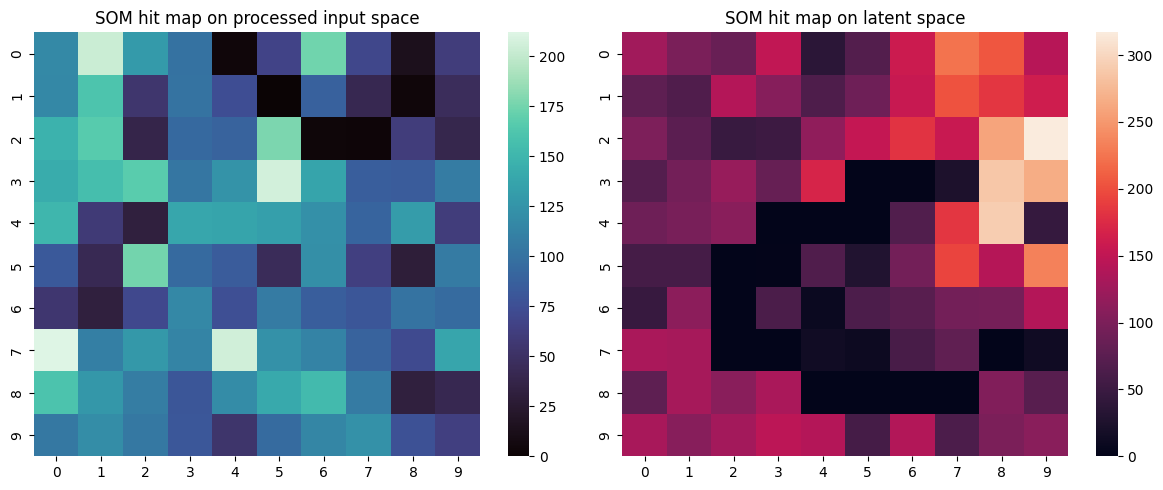

In [13]:
def compute_som_hits(som, data, labels):
    """Return a hit map and BMU positions for labeled data."""
    grid = np.zeros((som_side, som_side))
    rows = []
    for i, x in enumerate(data):
        winner = som.winner(x)
        grid[winner] += 1
        rows.append((winner[0], winner[1], labels[i]))
    return grid, pd.DataFrame(rows, columns=['row', 'col', 'label'])

input_hit_map, input_positions = compute_som_hits(som_input, X_test, y_test.to_numpy())
latent_hit_map, latent_positions = compute_som_hits(som_latent, Z_test_scaled, y_test.to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(input_hit_map, cmap='mako', ax=axes[0])
axes[0].set_title('SOM hit map on processed input space')
sns.heatmap(latent_hit_map, cmap='rocket', ax=axes[1])
axes[1].set_title('SOM hit map on latent space')
plt.tight_layout()
plt.show()


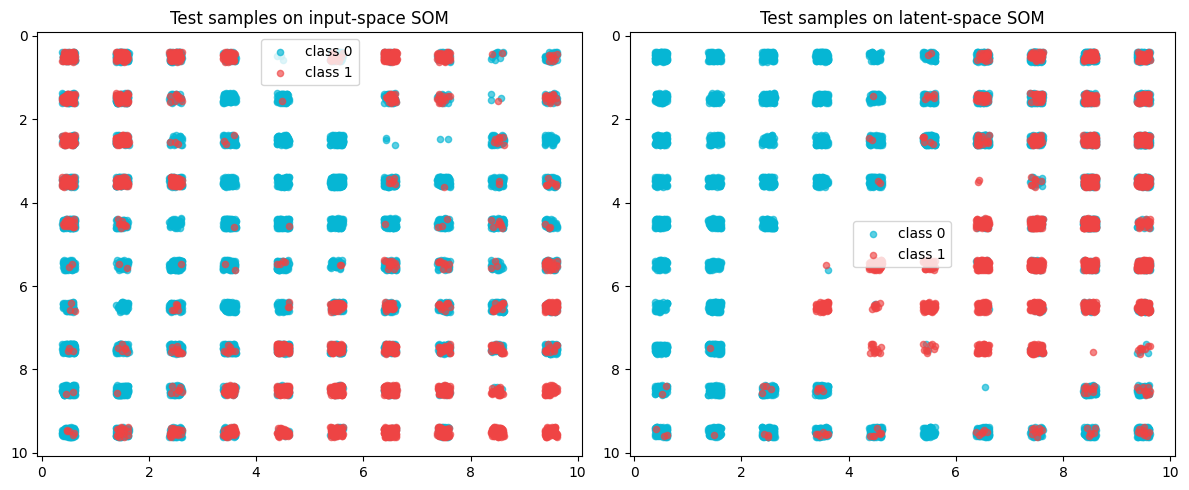

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, color in [(0, '#06b6d4'), (1, '#ef4444')]:
    subset = input_positions[input_positions['label'] == label]
    axes[0].scatter(subset['col'] + 0.5 + np.random.uniform(-0.12, 0.12, len(subset)), subset['row'] + 0.5 + np.random.uniform(-0.12, 0.12, len(subset)), s=20, c=color, alpha=0.65, label=f'class {label}')
axes[0].invert_yaxis()
axes[0].set_title('Test samples on input-space SOM')
axes[0].legend()

for label, color in [(0, '#06b6d4'), (1, '#ef4444')]:
    subset = latent_positions[latent_positions['label'] == label]
    axes[1].scatter(subset['col'] + 0.5 + np.random.uniform(-0.12, 0.12, len(subset)), subset['row'] + 0.5 + np.random.uniform(-0.12, 0.12, len(subset)), s=20, c=color, alpha=0.65, label=f'class {label}')
axes[1].invert_yaxis()
axes[1].set_title('Test samples on latent-space SOM')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Compact comparison

This table summarizes what each explanation method contributes on the same neural network and dataset.

In [15]:
comparison_df = pd.DataFrame([
    {'method': 'SHAP', 'scope': 'local + global', 'model_specific': 'yes for DeepExplainer', 'strength': 'stronger feature attribution fidelity for deep models', 'output': 'global importance and per-instance contributions'},
    {'method': 'LIME', 'scope': 'local', 'model_specific': 'no', 'strength': 'quick local sanity checks via surrogate linear model', 'output': 'per-instance local feature weights'},
    {'method': 'SOM', 'scope': 'global structure', 'model_specific': 'optional', 'strength': 'visualizes sample organization in input or latent space', 'output': '2D topology / hit maps'}
])
comparison_df


,method,scope,model_specific,strength,output
0,SHAP,local + global,yes for DeepExplainer,stronger feature attribution fidelity for deep...,global importance and per-instance contributions
1,LIME,local,no,quick local sanity checks via surrogate linear...,per-instance local feature weights
2,SOM,global structure,optional,visualizes sample organization in input or lat...,2D topology / hit maps


## 12. Notes and extensions

This notebook is intentionally minimal but complete. Natural next steps are SHAP beeswarm plots, repeated LIME explanations for multiple instances, SOM U-matrix visualization, and export cells for saving lecture figures.